# Coding Session 04 · Lab W4 · SOLUTIONS


## Today's plan

1. Return to Coding Session 03's robocall experiment and compare its three call arms.
2. Distinguish one comparison chosen in advance from searching for a winner.
3. Adapt the lab's simulation to count false alarms across several comparisons.
4. Use Coding Session 03's Pons experiment to examine subgroup differences.

We build on Week 3's difference in means and permutation test. Today's new
question is **what changes when we inspect several results and report the best one?**


Use the same table, simulation, and plotting libraries as the lab and live coding.
The filtering, group means, loops, and percentage-point units build on Week 3.


In [1]:
# Use the same libraries as the Week 4 lab and live coding.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
#@title Formatting helper — run once before the answer cells
from IPython.core.magic import register_cell_magic
from IPython.display import HTML, display
import mistune


class _TABoxRenderer(mistune.HTMLRenderer):
    def __init__(self, accent, label_only=False):
        super().__init__(escape=True)
        self.accent = accent
        self.label_only = label_only

    def heading(self, text, level):
        margin = '0' if self.label_only else '0 0 8px'
        return (f'<h{level} style="margin:{margin};font-size:13px;font-weight:750;'
                f'letter-spacing:.04em;line-height:1.6;color:{self.accent};">'
                f'{text}</h{level}>\n')

    def paragraph(self, text):
        return f'<p style="margin:6px 0;">{text}</p>\n'


def _ta_box_html(body, kind='answer'):
    # The text stays in the answer cells; all color and layout settings live here.
    palettes = {
        'answer': ('#def2e3', '#167346', 'ta-answer'),
        'reference': ('#e7eef9', '#45566c', 'ta-reference'),
        'code': ('#e1edff', '#235da5', 'ta-code-label'),
    }
    if kind not in palettes:
        raise ValueError('Use %%ta_box answer, %%ta_box reference, or %%ta_box code.')
    background, accent, css_class = palettes[kind]
    render = mistune.create_markdown(renderer=_TABoxRenderer(accent, kind == 'code'))
    content = render(body.strip())
    padding = '12px 20px' if kind == 'code' else '16px 20px'
    return (
        '<div style="font-family:Arial,sans-serif;font-size:16px;line-height:1.6;'
        'max-width:100%;box-sizing:border-box;overflow-wrap:break-word;">'
        f'<div class="ta-block {css_class}" style="background-color:{background};'
        f'color:#18232e;border:1px solid {accent};border-left:6px solid {accent};'
        f'padding:{padding};margin:12px 0;border-radius:6px;line-height:1.6;">'
        f'{content}</div></div>'
    )


@register_cell_magic
def ta_box(line, cell):
    """Display the cell's Markdown in a colored box; do not execute it as Python."""
    display(HTML(_ta_box_html(cell, line.strip() or 'answer')))


print('Formatting ready. Edit the Markdown below a %%ta_box line, then run that cell.')


Formatting ready. Edit the Markdown below a %%ta_box line, then run that cell.


## The robocall experiment

Kling and Stratmann studied whether partisan get-out-the-vote calls changed
participation in the **November 2014 US general election**. The study covered
six states and selected households through landline phone numbers. **One row
in our file is one registered voter**. Assignment was to no calls, one call,
three calls, or six calls; `voted` records turnout, not candidate choice.

We use an unchanged copy of the same CSV as Coding Session 03. The extract has **539,567 voters and eight columns**. Its arm
counts are 135,331 controls, 135,920 one-call voters, 134,826 three-call voters,
and 133,490 six-call voters. We keep the full extract for the descriptive arm
comparisons. Assignment means an attempt to call, not that a voter answered.

| Column | Meaning and units |
|---|---|
| `group` | Assigned arm: `Control (No Call)`, `T1: 1 Call`, `T3: 3 Calls`, or `T6: 6 Calls`. |
| `treatment` | 1 = any call arm; 0 = control. |
| `voted` | 1 = voted in November 2014; 0 = did not vote. |
| `gen2012` | 1 = voted in the 2012 general election; 0 = did not vote. |
| `svh` | 1 = single-voter household; 0 = another household type. |
| `age` | Recorded age in years; some missing values. |
| `male` | Recorded male indicator, 1/0; some missing values. |
| `income` | Supplied income measure; some missing values. Exact source units are unverified; unused here. |

Assignment, turnout, past voting, and `svh` have no missing values. A mean of
`voted` is a **proportion**. Multiply a mean by 100 for a percentage and a
difference by 100 for **percentage points**.

**Design boundary.** Households were assigned within states. This extract has
neither household IDs nor state. Its arm means remain useful, but shuffling
individual voters across the file does not reproduce the study's assignment.

[Study](https://doi.org/10.1017/XPS.2022.16) ·
[Original replication archive](https://doi.org/10.7910/DVN/DMJ7EA) ·
[Course data notes](https://github.com/albertostefanelli/DSPC_coding_sessions/blob/master/wk04_message_testing/data/README.md)

**Source check: September 23, 2026.** The article was published online August
18, 2022, and appeared in the 2023 journal issue. It cites replication **V1
(2022)**. The archive could not be accessed to verify later corrections or match
this course extract to a release. We retain the existing CSV unchanged.


### Load this week's copy

Open this notebook from the `wk04_message_testing` folder. Both datasets are
already in its `data` folder. Use the lab's direct `pd.read_csv()` pattern to
read one file, then `.head()` to inspect its first five rows.

In Colab, create a runtime folder called `data` and upload
`kling_stratmann_subset.csv` and `pons_2018_teaching.csv` from this week's data
folder. Then run the same loading cells below. If running locally from the
repository root instead, use
`'wk04_message_testing/data/kling_stratmann_subset.csv'` in this cell.


In [3]:
# Read the supplied CSV directly, using the same function as the lab.
calls = pd.read_csv('data/kling_stratmann_subset.csv')
calls.head()


,age,income,male,svh,gen2012,treatment,group,voted
0,38.0,100000.0,1.0,0,1,1,T1: 1 Call,1
1,36.0,100000.0,0.0,0,1,1,T1: 1 Call,0
2,64.0,75000.0,1.0,0,0,0,Control (No Call),0
3,63.0,75000.0,0.0,0,0,0,Control (No Call),0
4,21.0,100000.0,0.0,0,0,0,Control (No Call),0


As in the lab setup, `.shape` reports the number of rows and columns.


In [4]:
# Inspect the table dimensions, as in the lab setup.
calls.shape


(539567, 8)

## Compare each arm with the same control

The lab compares message content and survey vote intention. We adapt its
calculation to **assigned call intensity and recorded turnout**. The arithmetic
is the same, but a turnout effect is not a change in candidate support.

The familiar `groupby('group')['voted'].mean()` pattern splits rows by assignment,
selects the outcome column, and averages it within each arm. Because `voted` is
0 or 1, the mean is the proportion who voted.


In [5]:
# Display mean turnout in every assigned arm, as in Part 1 of live coding.
calls.groupby('group')['voted'].mean()


group
Control (No Call)    0.488639
T1: 1 Call           0.490833
T3: 3 Calls          0.495112
T6: 6 Calls          0.489437
Name: voted, dtype: float64

### Calculate the control mean

Copy the lab's filtering pattern: `calls['group'] == 'Control (No Call)'`
marks control rows, and `calls[is_control]` keeps them. Select `['voted']` and
use `.mean()` to calculate control turnout.

The lab uses **f-strings** to display results: the `f` before the quotes allows
values inside `{...}`. `:.3f` displays three decimal places, while `:+.3f` also
shows the sign. This changes the display only. Multiply proportions by 100
for percentages, and differences by 100 for percentage points.


In [6]:
# Calculate the shared control mean once, following the lab.
is_control = calls['group'] == 'Control (No Call)'
control_mean = calls[is_control]['voted'].mean()
print(f'Control turnout: {100 * control_mean:.3f}%')


Control turnout: 48.864%


### Work through one arm

Keep the one-call rows, average their turnout, and subtract the control mean.
This is one iteration of the loop we will write next.


In [7]:
# Take one-call turnout minus control turnout.
arm_mean = calls[calls['group'] == 'T1: 1 Call']['voted'].mean()
diff = arm_mean - control_mean
print(f'One-call turnout: {100 * arm_mean:.3f}%; difference: {100 * diff:+.3f} pp')


One-call turnout: 49.083%; difference: +0.219 pp


### Repeat with the lab's arm loop

A **list** stores several values in order. `for arm in treatment_arms:` takes
one label at a time from the list. The indented lines run for that label.
Each comparison uses the same control mean. We change only the table, column,
and arm names from the lab's example.


In [8]:
# Repeat the same mean-and-subtract calculation for all three treatment arms.
treatment_arms = ['T1: 1 Call', 'T3: 3 Calls', 'T6: 6 Calls']
for arm in treatment_arms:
    arm_mean = calls[calls['group'] == arm]['voted'].mean()
    diff = arm_mean - control_mean
    print(f'{arm}: turnout = {100 * arm_mean:.3f}%; difference = {100 * diff:+.3f} pp')


T1: 1 Call: turnout = 49.083%; difference = +0.219 pp
T3: 3 Calls: turnout = 49.511%; difference = +0.647 pp
T6: 6 Calls: turnout = 48.944%; difference = +0.080 pp


## One comparison and a search answer different questions

### Decide what belongs to the comparison family

A **comparison family** is the set of results we would inspect to support the
same decision. Here the campaign could choose one, three, or six calls after
looking at each arm's difference from control. That is **three comparisons**:
the shared control is a reference group, not a fourth treatment comparison.

| Decision rule | What is examined? | Where can chance enter? |
|---|---|---|
| Specify three calls versus control before seeing outcomes | One specified contrast | Noise in that contrast |
| Inspect all call arms, then choose the largest estimate | Three contrasts | Noise in each contrast and in which one wins |
| Inspect each call arm separately for past voters and non-voters | Six contrasts | Three arms × two subgroups |

The arithmetic within each row is still treatment mean minus control mean.
What changes is the **rule used to select the result we highlight**. Reporting
only the winning row does not turn a search over three rows into one planned test.
The family includes comparisons that could have changed the decision, including
unreported results, alternative subgroups, and outcomes inspected along the way.


### A 5% rule for one result is not a 5% rule for the whole search

Suppose every call intensity has zero true effect. A valid 5% test chosen in
advance produces at most 50 false alarms per 1,000 experiments **on average**.
Any particular set of 1,000 experiments may produce more or fewer.
That is a **per-comparison** statement. It does not say that only 5% of
experiments will contain any false alarm after several comparisons.

For the campaign's search, count an experiment as a false alarm if **at least
one** comparison passes the rule. An experiment with two false alarms still
counts once. This probability is called the **family-wise error rate**.
When some effects are real, the family-wise error still means at least one
false rejection among the hypotheses whose nulls are true.

For example, suppose comparison A gives false alarms in experiments 4 and 9,
and comparison B gives false alarms in 9 and 12. There are three affected
experiments: 4, 9, and 12. Adding the two counts gives four and double-counts
experiment 9. This is why our simulation records a True/False result for each
whole experiment, rather than adding all significant arms.


### Start with an independence benchmark

If each test has false-alarm probability 0.05 and the tests are independent,
one test avoids a false alarm with probability 0.95. All $m$ tests avoid one
with probability $0.95^m$. Subtract from one to get the probability of
**at least one** false alarm:

$$P(\text{at least one false alarm}) = 1 - (1 - 0.05)^m.$$

This calculation assumes that all tested effects are zero. The table below
shows how the probability changes as the number of comparisons increases.


| Number of independent comparisons | Probability of at least one false alarm |
|---:|---:|
| 1 | 5.00% |
| 2 | 9.75% |
| 3 | 14.26% |
| 4 | 18.55% |
| 10 | 40.13% |


Three independent 5% tests give about **14.3%**, not 5%. Four give **18.5%**,
the lab's slide example; ten give **40.1%**. These numbers are probabilities
across repeated no-effect experiments. They are **not** the probability that
our observed three-call estimate is false.

The expected *number* of false alarms is a different quantity: if each of three
tests has an exact 5% false-alarm rate, it is 3 × 0.05 = 0.15 per experiment, even if the tests are
dependent. That is not the probability of any false alarm, because an
experiment can contain more than one.


### Why the robocall comparisons are dependent

All three differences subtract the **same estimated control mean**. If chance
makes control turnout unusually low, all three treatment-minus-control gaps
rise together. If control turnout is high, all three gaps fall together.
The estimates therefore share a source of noise.

We should not read 14.3% from the independence formula as this experiment's
exact error rate. The lab's simulation handles a shared control by generating
it once per fake experiment and reusing it for every arm. Simulating a fresh
control for each call arm would describe a different design.

Dependence does not make the search disappear. It changes how often the
different comparisons produce false alarms together. The relevant event
remains **at least one comparison in the family crosses the cutoff**.


### The winner's curse is about the size of the selected estimate

Each estimate combines a true effect and sampling noise. When we pick the
largest estimate, we also tend to pick favorable noise. Consider this
illustration, where all three true effects are zero:

| Call arm | True effect | Chance contribution | Observed estimate |
|---|---:|---:|---:|
| One call | 0 pp | −0.7 pp | −0.7 pp |
| Three calls | 0 pp | +1.2 pp | +1.2 pp |
| Six calls | 0 pp | −0.3 pp | −0.3 pp |

Choosing three calls selects +1.2 pp even though its true effect is zero.
These are illustrative numbers, not our data. In the actual extract, three
calls also has the largest positive estimate, but the observed ranking alone
does not show that its true effect is largest.

Two issues are related but distinct. **Multiple testing** raises the chance of
at least one false alarm. **The winner's curse** can make the selected effect
too optimistic as a planning figure, including when some effects are real.
Adjusting a significance rule does not automatically remove bias from the
selected effect estimate.

Our lab-style simulation uses a **two-sided** cutoff: a sufficiently negative
gap also counts as a false alarm. A negative gap would not be a positive
campaign winner. Keep that error-counting rule separate from selecting the
largest positive estimate.


## Simulate the whole search with the lab's code

### A deliberately simple no-effect experiment

Use the lab's binomial simulation, arm slices, and nested loops. We adapt its
four message arms to **three call arms plus one control**, with 1,000 outcomes
per group. The no-effect turnout probability is **0.49 in every group**, close
to the robocall control mean. Equal probabilities make every treatment effect
zero, so any apparent effect crossing the rule is a false alarm.

This is a teaching model, not a new dataset or a test of the robocall study.
Its 4,000 independent outcomes do not reproduce the real sample sizes,
households, or assignment within states. The extract lacks the household and
state identifiers needed for that inference. We use the model to isolate
**what searching several arms does to an error rate**.

`np.random.binomial(1, 0.49, size=2000)` generates 2,000 independent 0/1
outcomes, each with probability 0.49 of being 1. In an array slice, the start
position is included and the stop is excluded: `[:1000]` is the first 1,000
values and `[1000:2000]` is the next 1,000. These slice and generation patterns
are the same ones used in the Week 4 lab.


### Set a cutoff for one comparison

The lab obtains its cutoff from the absolute null gaps already generated by
its permutation test. Here we generate null gaps directly from the stated
binomial model, because we cannot reproduce the robocall assignment design.
The subsequent cutoff and multiple-comparisons code follow the lab.

Reuse Week 3's repeated mean-difference logic. `[]` starts a list and
`.append(gap)` adds one result. Reset the random seed for reproducibility.
We only need a reference cutoff here; we do not compute a p-value for the
observed robocall estimates.


In [9]:
# Generate no-effect gaps for one treatment-versus-control comparison.
np.random.seed(2026)
fake_ates = []
for i in range(1000):
    fake_votes = np.random.binomial(1, 0.49, size=2000)
    fake_control_mean = fake_votes[:1000].mean()
    fake_treated_mean = fake_votes[1000:2000].mean()
    fake_ate = fake_treated_mean - fake_control_mean
    fake_ates.append(fake_ate)


The lab writes `[abs(f) for f in fake_ates]`: take each gap, call it `f`,
remove its sign with `abs()`, and collect the results in a list.
`np.percentile(values, 95)` finds the 95th percentile of those magnitudes.
This sets an approximate two-sided 5% cutoff for **one** comparison, before
any search. It has not been made stricter for three comparisons.

Binary outcomes create ties and we use finitely many simulations. Therefore
the fraction crossing this estimated cutoff need not be exactly 5%.


In [10]:
# Use the lab's percentile rule for a single comparison.
threshold = np.percentile([abs(f) for f in fake_ates], 95)
print(f'Single-comparison cutoff: {100 * threshold:.2f} percentage points')


Single-comparison cutoff: 4.50 percentage points


### Keep one control when checking three arms

First generate one fake experiment with 4,000 outcomes. The first 1,000 form
control; each following group of 1,000 forms a call arm. All four groups use
the same no-effect probability. A fresh seed starts a separate simulation
sequence from the one used to estimate the cutoff.


In [11]:
# One control and three treatment groups, all with zero true effect.
np.random.seed(42)
fake_votes = np.random.binomial(1, 0.49, size=4000)
fake_control_mean = fake_votes[:1000].mean()


`range(3)` supplies positions 0, 1, and 2. `treatment_arms[j]` selects the
corresponding call label. The first treatment slice starts at
`1000 * (j + 1)`; its end is 1,000 positions later.

`any_significant` starts False. Once an `if` condition finds a crossing it
becomes True and stays True, even if another arm does not cross. This records
one result for the whole experiment. A separate display for each arm lets us
see how that experiment-level result is formed.


In [12]:
# Follow the lab's one-experiment loop, reusing the same control mean.
any_significant = False
for j in range(3):
    arm_start = 1000 * (j + 1)
    arm_end = arm_start + 1000
    arm_mean = fake_votes[arm_start:arm_end].mean()
    diff = arm_mean - fake_control_mean
    crosses_cutoff = abs(diff) >= threshold
    print(f'{treatment_arms[j]}: {100 * diff:+.2f} pp; crosses cutoff: {crosses_cutoff}')
    if crosses_cutoff:
        any_significant = True
print('At least one false alarm:', any_significant)


T1: 1 Call: +2.30 pp; crosses cutoff: False
T3: 3 Calls: +0.40 pp; crosses cutoff: False
T6: 6 Calls: -1.00 pp; crosses cutoff: False
At least one false alarm: False


### Compare a fixed decision with the search, in the same experiments

Now repeat the fake experiment 1,000 times. Count two events separately:

1. **One fixed comparison:** the first call arm crosses the cutoff.
2. **The search:** any of the three call arms crosses the same cutoff.

Both rules see the same generated experiment. The only difference is whether
we inspect one specified arm or all three. The first event is contained in
the second: whenever the first arm crosses, at least one arm has crossed.
The search count therefore cannot be smaller.


In [13]:
# Reset the sequence so this whole comparison is reproducible.
np.random.seed(42)
single_false_positive_count = 0
false_positive_count = 0


The outer loop generates experiments and the inner loop checks arms. Reset
`any_sig` in each experiment. `break` stops checking arms after the first
crossing, because that experiment already counts as affected. `+= 1` adds one
to a counter. These are the lab's counting steps; the extra first-arm counter
lets us compare the two decision rules directly.


In [14]:
# Apply a fixed one-arm rule and the three-arm search to identical fake data.
for i in range(1000):
    fake_votes = np.random.binomial(1, 0.49, size=4000)
    fake_control_mean = fake_votes[:1000].mean()
    first_gap = fake_votes[1000:2000].mean() - fake_control_mean
    if abs(first_gap) >= threshold:
        single_false_positive_count += 1
    any_sig = False
    for j in range(3):
        arm_mean = fake_votes[1000 * (j + 1):1000 * (j + 2)].mean()
        if abs(arm_mean - fake_control_mean) >= threshold:
            any_sig = True
            break
    if any_sig:
        false_positive_count += 1


Divide each counter by the **1,000 experiments**, not by 3,000 comparisons.
The first fraction describes one fixed test. The second describes whether
the whole search produced at least one false alarm.


In [15]:
# Report the unit of counting explicitly: whole fake experiments.
print(f'One fixed arm: {single_false_positive_count} / 1000 = {single_false_positive_count / 1000:.3f}')
print(f'Any of three arms: {false_positive_count} / 1000 = {false_positive_count / 1000:.3f}')


One fixed arm: 45 / 1000 = 0.045
Any of three arms: 108 / 1000 = 0.108


The difference comes from opportunities for an alarm in the other arms.
All true effects remained zero. A larger search error rate does not mean
that each individual test became worse; it means that the decision rule
changed from “check this arm” to “find any arm that passes.”

Do not expect the exact independence benchmark: the comparisons share a
control, the cutoff was estimated, and only 1,000 experiments were generated.
More repetitions improve simulation precision but do not remove the search.
These simulated fractions do not establish a p-value or correction for the
actual robocall study.


### See which gaps pass the unchanged single-comparison rule

Reuse the histogram from the lab. `plt.figure()` sets its size;
`plt.hist()` bins the generated gaps; `plt.axvline()` marks the two cutoffs.
`plt.xlabel()` and `plt.ylabel()` label the axes; `plt.title()` adds a title;
`plt.legend()` identifies the lines; `plt.tight_layout()` adjusts spacing;
`plt.show()` displays the result. These are the live-coding functions.
Each bar describes gaps for **one** comparison; checking more
arms gives the experiment more chances to land beyond either red line.


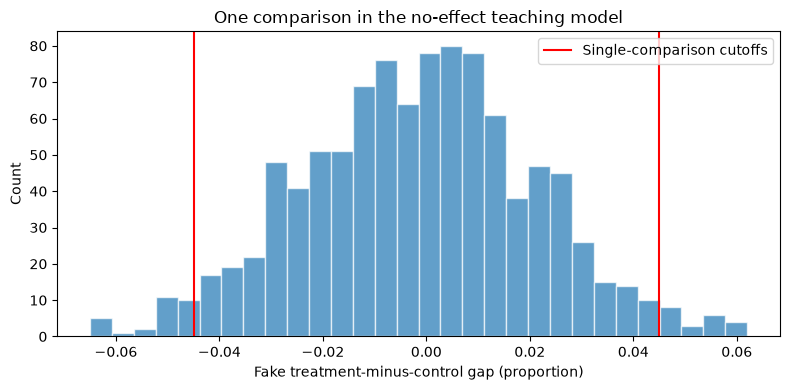

In [16]:
# Display the reference gaps and both sides of the single-comparison rule.
plt.figure(figsize=(8, 4))
plt.hist(fake_ates, bins=30, edgecolor='white', alpha=0.7)
plt.axvline(threshold, color='red', label='Single-comparison cutoffs')
plt.axvline(-threshold, color='red')
plt.xlabel('Fake treatment-minus-control gap (proportion)')
plt.ylabel('Count')
plt.title('One comparison in the no-effect teaching model')
plt.legend()
plt.tight_layout()
plt.show()


## Subgroups create the same search problem

Multiple treatment arms are not required. With one treatment and one control,
we might inspect effects separately among past voters and non-voters, or
among precincts and municipalities. Those are multiple chances to find a
promising estimate. If we also inspect turnout and candidate share, two
subgroups × two outcomes creates **four** within-subgroup comparisons.

Choose groups using characteristics defined before treatment. A subgroup
defined by whether someone answered a treatment call would instead condition
on something the intervention can change. Calling a search “exploratory” is
useful disclosure, but it does not eliminate its uncertainty.

### A subgroup effect and heterogeneity are different claims

“Canvassing works in municipalities” asks whether the municipality effect is
zero. “Canvassing works better in municipalities than precincts” asks whether
the **difference between those two effects** is zero:

$$\text{heterogeneity contrast} =
(\bar Y_{T,M} - \bar Y_{C,M}) - (\bar Y_{T,P} - \bar Y_{C,P}).$$

First subtract treatment minus control within each group; then subtract the
two effects. Do not compare raw treated means across groups, because their
control outcomes can differ too. A significant result in one subgroup and a
non-significant result in another does **not** establish that their effects
differ: the estimates may have different uncertainty. The difference itself
needs an appropriate comparison and uncertainty calculation.
See [Gelman and Stern (2006)](https://doi.org/10.1198/000313006X152649)
for this distinction.

In the exercise we calculate this contrast descriptively. A formal test of it
would be a distinct hypothesis; if searched alongside the two subgroup tests,
it would add another comparison to that decision's family.


## What changes in a campaign recommendation?

**Define the decision before inspecting results.** Specify a primary outcome,
contrast, and subgroup in advance. Secondary comparisons can be useful, but
report them together with the full search that produced them. Making a plan
after seeing the winner does not make it pre-specified.

**Use a rule for the whole family when making confirmatory claims.** For
example, Bonferroni divides a 5% family error budget across `m` valid tests:
compare each p-value with `0.05 / m`. With three tests this is about 0.0167.
The probability of any false rejection is bounded by the sum of the individual
error probabilities, so this safeguard does not require independent tests.
It can be conservative and miss real effects. It requires valid individual
tests, cannot repair an incorrect assignment model, and does not shrink an
exaggerated winning effect estimate. We do not apply it to the robocall extract
because we cannot construct the required design-based tests from its columns.
The [NIST explanation of Bonferroni](https://www.itl.nist.gov/div898/handbook/prc/section4/prc473.htm)
gives the probability bound behind this rule.

**Separate selection from confirmation.** Select a promising intervention,
then assess it in an independent randomized test with the comparison and
decision rule fixed. Do not treat another subgroup of the same searched data
as an independent confirmation. Consider effect size, uncertainty, cost, and
the intended delivery setting together. The largest point estimate need not
give the best return per dollar or reproduce at a new scale.


## Exercise: heterogeneity in the Coding Session 03 canvassing experiment

Return to **Pons (2018)**, the experiment used in Coding Session 03's exercise.
It has one treatment pool and one control group, not several message arms.
We therefore compare estimates across the existing `area_type` categories:
**Municipality** and **Precinct**. Use `hollande_share` as the primary outcome.

Copy and adapt the preceding filtering, mean-difference, list, and simulation
code. The substantive calculations belong in the blank answer cells.


### Study, sample, and variables

During François Hollande's 2012 French presidential campaign, volunteers
canvassed residents about the election and candidate. Areas were randomized
within local blocks to a treatment pool or control, usually four to one.
The campaign subsequently selected areas from the treatment pool for canvassers
to cover. Assignment therefore does not mean that every area was visited.

One row is a randomization area: either a precinct or a whole municipality.
`area_type` describes that pre-existing unit; it was not itself randomized.
The **unchanged Coding Session 03 extract has 3,397 areas**: 1,713 precincts
and 1,684 municipalities, including 2,723 treatment areas and 674 controls
across 733 blocks. All blocks in this extract contain only one area type.
The exercise retains every row; each area receives equal weight.

The original 17,242-row analysis file was restricted to the paper's main-sample
territories (`territory_in == 1`, 4,674 areas), then to matched 2012 election
returns (`merge_results12 == 1`, 3,397 areas). The existing extract has eight
columns with no missing values; we make no further sample restrictions.

| Column | Meaning and coding |
|---|---|
| `area_id` | Unique area identifier constructed from the original geographic codes. |
| `area_type` | `Municipality` or `Precinct`; subgroup used in this exercise. |
| `municipality` | Municipality name; several precincts may share it. |
| `block` | Local randomization block identifier. |
| `treatment` | 1 = assigned to treatment pool; 0 = control. |
| `registered` | Number of registered voters in the first round. |
| `turnout` | Ballots cast / registered voters in the first round. |
| `hollande_share` | Hollande votes / valid candidate votes in the first round; blank and invalid ballots are excluded. |

The outcomes refer to **April 22, 2012** and are proportions, not individual
0/1 votes. Multiply means by 100 for percentages and differences by 100 for
percentage points. Mean area shares are not voter-weighted national totals.
Our unadjusted assignment contrasts need not equal the paper's block-adjusted
estimates. They do not estimate effects per person actually contacted.

[Original study](https://doi.org/10.1257/aer.20160524) ·
[Original replication archive](https://www.openicpsr.org/openicpsr/project/113130/version/V1/view) ·
[Preparation and data notes](data/README.md)

**Version checked September 24, 2026:** the journal article is from June 2018.
The original archive lists **V1, October 12, 2019**, as its only published
version; no newer release or correction is listed there. Coding Session 03's
notes record downloading the journal replication ZIP on September 17, 2026.
We copy its prepared CSV byte for byte into this week's `data` folder.


### Load and inspect the same file

As in Coding Session 03, open this notebook from the Week 4 folder and load
`data/pons_2018_teaching.csv`. If your working folder is the repository root,
use `'wk04_message_testing/data/pons_2018_teaching.csv'` instead. In Colab,
create a runtime folder called `data` and upload the Week 4 CSV into it.

The provided code loads the file and displays its first rows and dimensions,
without calculating the
exercise's outcome means. Filtering each area type keeps its original
treatment/control assignments. No labels are shuffled in this exercise's
descriptive calculations. If doing further randomization inference, reuse
Coding Session 03's **within-block** assignment scheme, conditional on the
rows and arm counts retained in the extract.


In [17]:
# Load Week 4's unchanged copy of the Coding Session 03 exercise data.
pons = pd.read_csv('data/pons_2018_teaching.csv')
pons.head()


,area_id,area_type,municipality,block,treatment,registered,turnout,hollande_share
0,M_77208,Municipality,Gouaix,2914,1,990,0.774747,0.253333
1,M_91156,Municipality,Cheptainville,3324,0,1243,0.839099,0.263209
2,P_94068_31,Precinct,Saint-Maur-des-Fossés,3498,1,987,0.810537,0.285896
3,P_91421_4,Precinct,Montgeron,3363,0,979,0.785495,0.283622
4,P_94033_22,Precinct,Fontenay-sous-Bois,3481,1,941,0.776833,0.343137


In [18]:
# Inspect the table dimensions, as in the lab setup.
pons.shape


(3397, 8)

### 1. Estimate the assignment effect within each area type

For **Municipality first, then Precinct**, calculate control and treatment
means of `hollande_share`, and treatment minus control. Display means as
percentages and gaps as percentage points. Use the same arm-filtering and
mean-subtraction steps as the robocall example, now inside an area-type loop.

Create an empty list named `subgroup_effects`. Use `.append()` to save each
gap in **proportion units**, in the stated order. Which subgroup has the
larger positive estimate? Interpret it in Question 2.


In [19]:
%%ta_box code
### TA CODE ANSWER · Exercise 1


In [20]:
# Repeat the treatment-control contrast separately within each existing area type.
subgroup_effects = []
for area_type in ['Municipality', 'Precinct']:
    areas = pons[pons['area_type'] == area_type]
    control_mean = areas[areas['treatment'] == 0]['hollande_share'].mean()
    treated_mean = areas[areas['treatment'] == 1]['hollande_share'].mean()
    effect = treated_mean - control_mean
    subgroup_effects.append(effect)
    print(f'{area_type}: control = {100 * control_mean:.3f}%; treatment = {100 * treated_mean:.3f}%; effect = {100 * effect:+.3f} pp')


Municipality: control = 27.147%; treatment = 28.267%; effect = +1.120 pp
Precinct: control = 35.924%; treatment = 36.026%; effect = +0.101 pp


### 2. Compare effects, not just treated means

**a. Calculate** the municipality effect minus the precinct effect, in
percentage points. The effects list uses positions just like the arm list:
`subgroup_effects[0]` is Municipality and `[1]` is Precinct.


In [21]:
%%ta_box code
### TA CODE ANSWER · Exercise 2a


In [22]:
# Take a difference between the two assignment-effect estimates.
heterogeneity_gap = subgroup_effects[0] - subgroup_effects[1]
print(f'Municipality minus precinct effect: {100 * heterogeneity_gap:+.3f} percentage points')


Municipality minus precinct effect: +1.019 percentage points


**b. Explain in three or four sentences.** Which subgroup has the larger
estimated effect, and what does the difference between effects mean? Does this
calculation establish a true difference in effects? If one subgroup's test
were significant and the other's were not, would that establish heterogeneity?
Finally, if we searched both `turnout` and `hollande_share` in both area types,
how many within-subgroup comparisons would be in that search family?


In [23]:
%%ta_box answer
### TA MODEL ANSWER · Exercise 2b

Municipalities have the larger estimated vote-share effect: +1.120 pp,
compared with +0.101 pp for precincts. The municipality-minus-precinct
effect difference is +1.019 pp, but this descriptive calculation does
not establish that the true effects differ or that changing an area's type
would change the effect. A significant effect in one group and a non-significant
effect in the other would not establish heterogeneity; we would need an
appropriate uncertainty calculation for the difference itself. Searching two
outcomes in two area types gives four within-subgroup comparisons; separately
testing heterogeneity as part of that search would add another hypothesis.


### 3. Adapt the lab simulation to searching two subgroups

**a. Simulate** a simple no-effect world with two disjoint subgroups, each
containing its own 1,000 controls and 1,000 treated observations. Copy and
adapt the walkthrough's repeated fake-experiment loop. Use seed 42, 1,000
experiments, and `np.random.binomial(1, 0.49, size=4000)` each time.

Store subgroup 1 in positions 0–1,999 and subgroup 2 in positions 2,000–3,999.
Within each subgroup, the first 1,000 positions are control and the next
1,000 are treatment. In an inner loop with `range(2)`, `2000 * j` gives the
subgroup's starting position. Move both the control and treatment slices to
that subgroup: **there is no shared control across these two comparisons**.

Use the walkthrough's `threshold`, since each comparison still has 1,000
controls and 1,000 treated outcomes under the same model. Count an experiment
once if **either** subgroup's absolute gap crosses it. Report the count and
fraction. You can adapt the earlier `any_sig`, `break`, and counter code.

This model illustrates searching two subgroups. Its independent binary
observations, equal sample sizes, and probability 0.49 do **not** reproduce
Pons's area vote shares, sample sizes, or block randomization. Do not apply
its numerical cutoff or error rate to the real Pons estimates.


In [24]:
%%ta_box code
### TA CODE ANSWER · Exercise 3a


In [25]:
# Give each subgroup a separate control while retaining the lab's loop structure.
np.random.seed(42)
subgroup_false_positive_count = 0
for i in range(1000):
    fake_votes = np.random.binomial(1, 0.49, size=4000)
    any_sig = False
    for j in range(2):
        group_start = 2000 * j
        fake_control_mean = fake_votes[group_start:group_start + 1000].mean()
        fake_treated_mean = fake_votes[group_start + 1000:group_start + 2000].mean()
        if abs(fake_treated_mean - fake_control_mean) >= threshold:
            any_sig = True
            break
    if any_sig:
        subgroup_false_positive_count += 1
print(f'At least one false subgroup alarm: {subgroup_false_positive_count} / 1000')
print(f'Fraction: {subgroup_false_positive_count / 1000:.3f}')


At least one false subgroup alarm: 82 / 1000
Fraction: 0.082


**b. Interpret in three or four sentences.** Compare your fraction with the
independence benchmark for two exactly 5% tests. Explain why searching subgroups
can produce a false winner even with only one treatment arm. What can this
simulation tell us about the Pons exercise, and what can it not tell us?
Suggest one step before recommending canvassing only in the apparently
more responsive area type.


In [26]:
%%ta_box answer
### TA MODEL ANSWER · Exercise 3b

The simulation produced 82 affected experiments out of 1,000
(8.2%), compared with the 9.75% benchmark for two independent,
exactly 5% tests; ties, the estimated cutoff, and finite repetitions account
for differences. Even with one treatment arm, searching two subgroup effects
provides two chances for a false positive. This illustrates the selection
problem but gives neither a Pons p-value nor evidence that its two true effects
differ, because the simulation does not reproduce that experiment's data or
assignment. Before targeting only municipalities, report both estimates and assess their
difference with uncertainty appropriate to the blocked design, then
pre-specify and confirm the targeting rule in an independent test.
